In [32]:
import os

files_dir  = "../Data/data_clip_exolabs"
#get all files in dir 
files = os.listdir(files_dir)
print(files)

#load tif 
import rasterio
import numpy as np
import matplotlib.pyplot as plt

tif_files = []
for file in files:
    src = rasterio.open(os.path.join(files_dir, file))
    tif_files.append(src.read(1))


['2023-04-27+000_alps_HS_product.tif', '2023-04-19+000_alps_HS_product.tif', '2023-06-25+000_alps_HS_product.tif', '2023-05-06+000_alps_HS_product.tif', '2023-05-09+000_alps_HS_product.tif', '2023-06-14+000_alps_HS_product.tif', '2023-04-16+000_alps_HS_product.tif', '2023-04-28+000_alps_HS_product.tif', '2023-04-05+000_alps_HS_product.tif', '2023-06-07+000_alps_HS_product.tif', '2023-05-24+000_alps_HS_product.tif', '2023-05-15+000_alps_HS_product.tif', '2023-06-08+000_alps_HS_product.tif', '2023-06-10+000_alps_HS_product.tif', '2023-04-12+000_alps_HS_product.tif', '2023-04-23+000_alps_HS_product.tif', '2023-05-02+000_alps_HS_product.tif', '2023-06-21+000_alps_HS_product.tif', '2023-05-11+000_alps_HS_product.tif', '2023-04-30+000_alps_HS_product.tif', '2023-04-01+000_alps_HS_product.tif', '2023-05-20+000_alps_HS_product.tif', '2023-06-03+000_alps_HS_product.tif', '2023-05-12+000_alps_HS_product.tif', '2023-04-02+000_alps_HS_product.tif', '2023-05-23+000_alps_HS_product.tif', '2023-06-13

In [38]:
with rasterio.open('../Data/data_clip_exolabs/2023-04-27+000_alps_HS_product.tif') as src:
    # Check metadata
    print(src.crs)  # Coordinate Reference System (CRS)
    print(src.bounds)  # Bounding box (min, max) coordinates
    print(src.transform)







EPSG:3857
BoundingBox(left=829059.4892686082, bottom=5860743.433705239, right=938039.4892686082, top=5927163.433705239)
| 20.00, 0.00, 829059.49|
| 0.00,-20.00, 5927163.43|
| 0.00, 0.00, 1.00|


In [49]:
file_path = '../Data/full_dataset.csv'

import pandas as pd

df = pd.read_csv(file_path)

# Extract the unique station codes along with their lon and lat
unique_stations = df[['station_code', 'lon', 'lat']].drop_duplicates()

unique_stations.dropna(inplace=True)
print(unique_stations)

from pyproj import Proj, transform


epsg4326 = Proj(init="epsg:4326")
epsg3857 = Proj(init="epsg:3857")

# Define the bounding box in EPSG:3857
bounding_box = {
    'left': 829059.4892686082,
    'bottom': 5860743.433705239,
    'right': 938039.4892686082,
    'top': 5927163.433705239
}
df = unique_stations
# Function to convert lon/lat to EPSG:3857
def lonlat_to_epsg3857(lon, lat):
    x, y = transform(epsg4326, epsg3857, lon, lat)
    return x, y

# Filter stations within the bounding box
stations_in_bbox = []

for index, row in df.iterrows():
    lon, lat = row['lon'], row['lat']
    
    # Convert to EPSG:3857
    x, y = lonlat_to_epsg3857(lon, lat)
    
    # Check if the station is within the bounding box
    if bounding_box['left'] <= x <= bounding_box['right'] and bounding_box['bottom'] <= y <= bounding_box['top']:
        stations_in_bbox.append(row['station_code'])

# Output the stations that are within the bounding box
print("Stations within the bounding box (EPSG:3857):")
print(stations_in_bbox)


/var/folders/lj/yyssz_p12f50nl5zkgxpqy5h0000gn/T/ipykernel_52568/1728435207.py:5: DtypeWarning: Columns (91) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)
/Users/ilyayakushevskiy/.pyenv/versions/3.12.0/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/ilyayakushevskiy/.pyenv/versions/3.12.0/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6


      station_code       lon        lat
3653          DIA2  7.241038  46.315405
3696          GLA2  9.037583  46.996629
3825          TUJ3  8.740224  46.647032
3913          OBW2  8.315956  46.545222
3957          URS2  8.513860  46.586787
...            ...       ...        ...
11082         KES2  9.898140  46.621285
11122         LAG2  9.744580  46.451358
11162         FUL2  7.089661  46.194685
11163         ILI2  6.827797  46.191356
11203         FIR2  8.064403  46.668777

[95 rows x 3 columns]
Stations within the bounding box (EPSG:3857):
['OBW2', 'GAD2', 'TIT2', 'FAE2', 'GUT2', 'OTT2', 'ROA2', 'SCH2', 'MAE2', 'SCB2', 'OBW3', 'TIT2', 'GAD2', 'OBW3', 'GUT2', 'ROA2', 'FIR2']


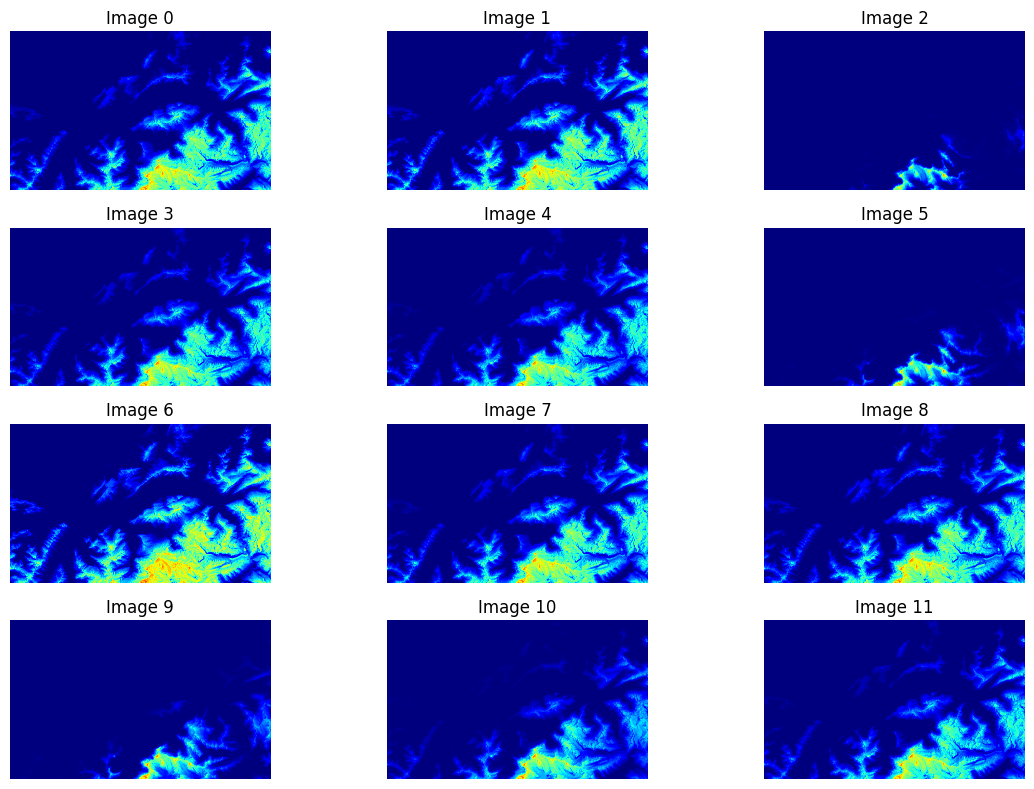

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 3, figsize=(12, 8))  

for i in range(12):
    ax = axes[i // 3, i % 3]
    ax.imshow(tif_files[i], cmap='jet') 
    ax.set_title(f"Image {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()


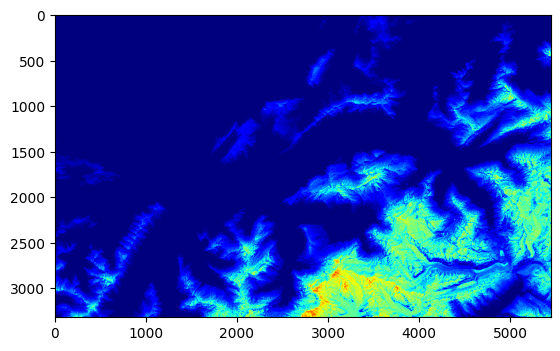

In [30]:
plt.imshow(tif_files[0], cmap='jet')